In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Configuración de estilo
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

print("✅ Librerías cargadas correctamente")

✅ Librerías cargadas correctamente


In [2]:
# Verificar si existen los datos descargados
datos_existentes = os.path.exists('DATOS/raw/wb_fbkf_pib.csv')

if datos_existentes:
    print("Cargando datos desde DATOS/raw/...")
    
    # Cargar datos
    df_fbkf = pd.read_csv('DATOS/raw/wb_fbkf_pib.csv')
    df_fiscal = pd.read_csv('DATOS/raw/wb_presion_fiscal.csv')
    df_eficiencia = pd.read_csv('DATOS/raw/wb_eficiencia_gobierno.csv')
    
    print(f"✅ FBKF: {len(df_fbkf)} observaciones")
    print(f"✅ Fiscal: {len(df_fiscal)} observaciones")
    print(f"✅ Eficiencia: {len(df_eficiencia)} observaciones")
    
    # Mostrar primeras filas
    display(df_fbkf.head())
    
else:
    print("⚠️ No se encontraron datos descargados.")
    print("Creando datos de ejemplo...")
    
    # Crear datos de ejemplo
    paises = ['ECU', 'PAN', 'CRI']
    años = list(range(2010, 2025))
    
    datos_ejemplo = {
        'ECU': {'FBKF': 21.0, 'trend': -0.35, 'Fiscal': 13.5},
        'PAN': {'FBKF': 26.0, 'trend': 0.0, 'Fiscal': 10.5},
        'CRI': {'FBKF': 20.5, 'trend': -0.1, 'Fiscal': 13.0}
    }
    
    # Generar FBKF
    fbkf_data = []
    for pais in paises:
        for año in años:
            valor = datos_ejemplo[pais]['FBKF'] + (datos_ejemplo[pais]['trend'] * (año - 2010))
            valor += np.random.uniform(-1, 1)
            fbkf_data.append({'economia': pais, 'año': año, 'FBKF_PIB': round(valor, 2)})
    
    df_fbkf = pd.DataFrame(fbkf_data)
    
    # Generar Fiscal
    fiscal_data = []
    for pais in paises:
        for año in años:
            valor = datos_ejemplo[pais]['Fiscal'] + np.random.uniform(-0.5, 0.5)
            fiscal_data.append({'economia': pais, 'año': año, 'Presion_Fiscal': round(valor, 2)})
    
    df_fiscal = pd.DataFrame(fiscal_data)
    
    # Generar Eficiencia
    efic_data = []
    for pais in paises:
        for año in años:
            valor = -0.6 if pais == 'ECU' else (0.4 if pais == 'PAN' else 0.7)
            valor += np.random.uniform(-0.1, 0.1)
            efic_data.append({'economia': pais, 'año': año, 'Eficiencia_Gobierno': round(valor, 2)})
    
    df_eficiencia = pd.DataFrame(efic_data)
    
    print("✅ Datos de ejemplo creados")
    display(df_fbkf.head())

⚠️ No se encontraron datos descargados.
Creando datos de ejemplo...
✅ Datos de ejemplo creados


,economia,año,FBKF_PIB
0,ECU,2010,21.98
1,ECU,2011,20.25
2,ECU,2012,20.03
3,ECU,2013,20.26
4,ECU,2014,20.32


In [3]:
# Unir los dataframes
df_panel = df_fbkf.merge(df_fiscal, on=['economia', 'año'], how='inner')
df_panel = df_panel.merge(df_eficiencia, on=['economia', 'año'], how='inner')

# Renombrar países para mejor visualización
map_paises = {'ECU': 'Ecuador', 'PAN': 'Panamá', 'CRI': 'Costa Rica'}
df_panel['Pais'] = df_panel['economia'].map(map_paises)

print(f"✅ Panel creado: {len(df_panel)} observaciones")
print(f"   Años: {df_panel['año'].min()} - {df_panel['año'].max()}")
print(f"   Países: {', '.join(df_panel['Pais'].unique())}")

# Mostrar estadísticas descriptivas
display(df_panel.describe())

✅ Panel creado: 45 observaciones
   Años: 2010 - 2024
   Países: Ecuador, Panamá, Costa Rica


,año,FBKF_PIB,Presion_Fiscal,Eficiencia_Gobierno
count,45.000000,45.000000,45.000000,45.000000
mean,2017.000000,21.378444,12.359333,0.164000
std,4.369314,3.388474,1.319732,0.559177
min,2010.000000,15.410000,10.210000,-0.680000
25%,2013.000000,19.110000,10.760000,-0.540000
50%,2017.000000,20.030000,13.000000,0.410000
75%,2021.000000,25.410000,13.270000,0.640000
max,2024.000000,26.750000,13.850000,0.800000


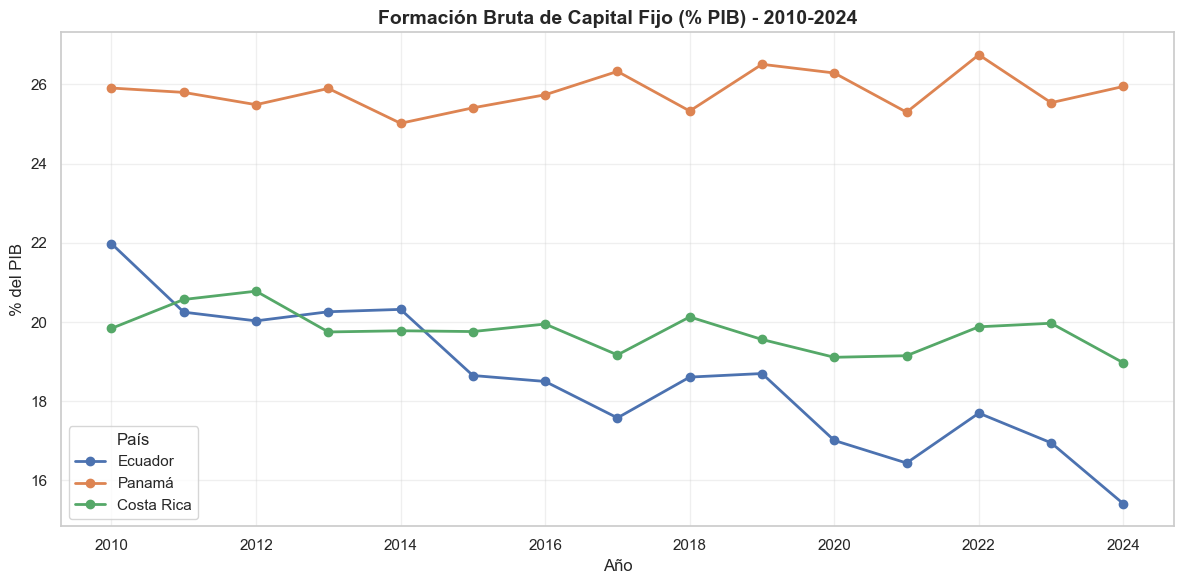

In [4]:
# Crear el gráfico
plt.figure(figsize=(12, 6))

# Usar los datos reales del panel
for pais in df_panel['Pais'].unique():
    df_pais = df_panel[df_panel['Pais'] == pais]
    plt.plot(df_pais['año'], df_pais['FBKF_PIB'], marker='o', linewidth=2, label=pais)

plt.title('Formación Bruta de Capital Fijo (% PIB) - 2010-2024', fontsize=14, fontweight='bold')
plt.xlabel('Año', fontsize=12)
plt.ylabel('% del PIB', fontsize=12)
plt.legend(title='País', loc='best')
plt.xticks(range(2010, 2025, 2))
plt.grid(True, alpha=0.3)

# Ajustar layout
plt.tight_layout()
plt.show()

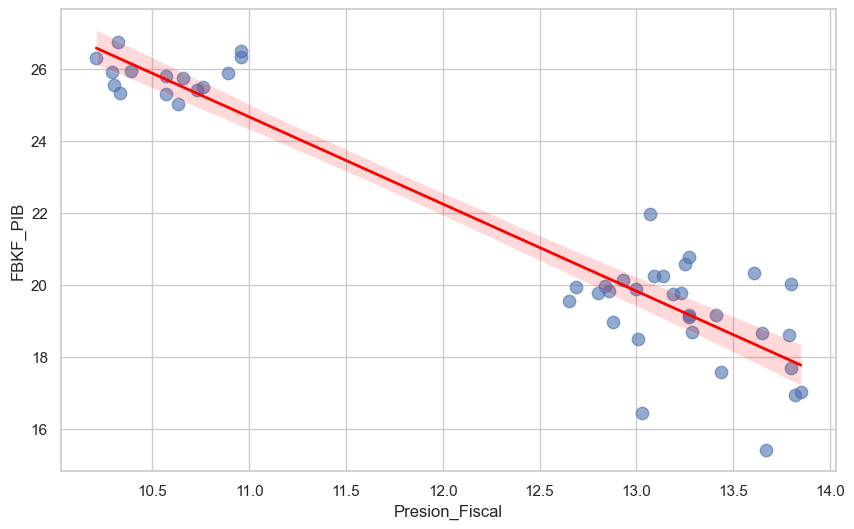

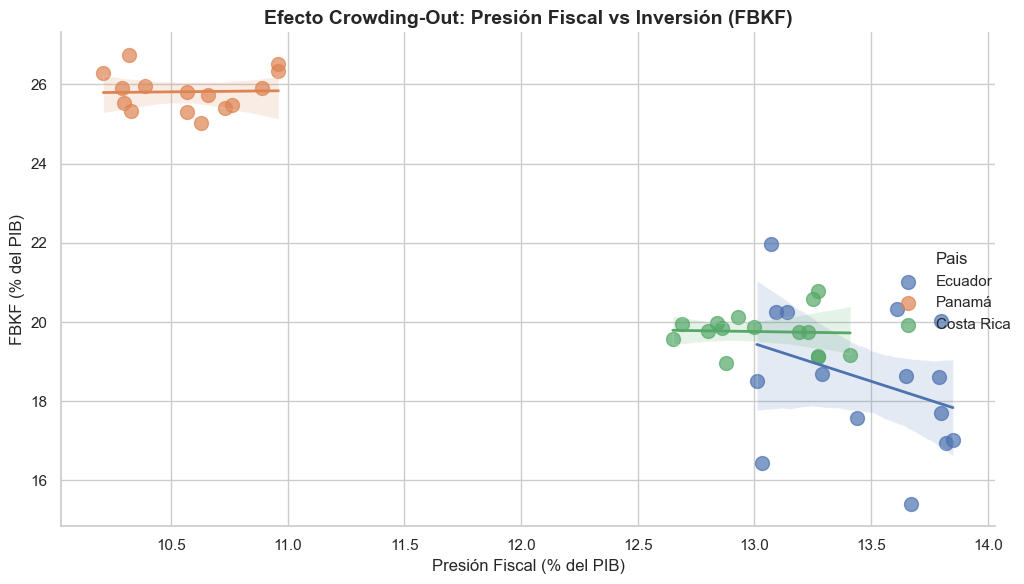

In [5]:
plt.figure(figsize=(10, 6))

# Scatter plot con línea de tendencia
sns.regplot(data=df_panel, x='Presion_Fiscal', y='FBKF_PIB', 
            scatter_kws={'alpha':0.6, 's':80}, line_kws={'color':'red', 'linewidth':2})

# Colorear por país
sns.lmplot(data=df_panel, x='Presion_Fiscal', y='FBKF_PIB', 
           hue='Pais', height=6, aspect=1.5,
           scatter_kws={'alpha':0.7, 's':100},
           line_kws={'linewidth':2})

plt.title('Efecto Crowding-Out: Presión Fiscal vs Inversión (FBKF)', 
          fontsize=14, fontweight='bold')
plt.xlabel('Presión Fiscal (% del PIB)', fontsize=12)
plt.ylabel('FBKF (% del PIB)', fontsize=12)

plt.tight_layout()
plt.show()